## Sameer Ramkissoon - random_forest.ipynb
Applying random forest to the cleaned Algerian forest fire dataset

In [19]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [20]:
# Initializing data and reading first few rows
df = pd.read_csv("data/algerian_forest_fires_proj4.csv")
df.head()

,region,temp_c,rel_humidity_percent,wind_speed_kmh,rainfall_mm,ffmc,dmc,dc,isi,bui,fwi,classes
0,Bejaia,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,Bejaia,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire
2,Bejaia,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,Bejaia,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire
4,Bejaia,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire


In [21]:
# Printing the shape of the dataset (243 instances only)
df.shape

(243, 12)

### Getting Training & Testing Data
- Dropping the region column (only focusing on numerical attributes and index codes for forest fires)
- Using K-Fold Cross Validation due to low number of instances

In [22]:
# Dropping region column
tested_df = df.drop('region', axis=1).copy()
tested_df.head()

,temp_c,rel_humidity_percent,wind_speed_kmh,rainfall_mm,ffmc,dmc,dc,isi,bui,fwi,classes
0,29.0,57.0,18.0,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,29.0,61.0,13.0,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire
2,26.0,82.0,22.0,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,25.0,89.0,13.0,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire
4,27.0,77.0,16.0,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire


In [23]:
# Using full dataset for training & testing
fire_data_x = tested_df.drop('classes', axis=1)
fire_data_y = tested_df['classes']

In [24]:
# Creating k-folds with 5 splits (4 train, 1 test) and shuffle instances
cross_validation = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### Creating Random Forest
- Using GridSearchCV to test various parameters and cross validation
- Fitting the data into the GridSearchCV to find best parameters

In [25]:
# Parameters for cross validation
# MAX_DEPTH, MAX_FEAT, CRITERION same as decision_tree.ipynb
# N_ESTIMATORS = number of independent decision trees
N_ESTIMATORS = [50, 100, 250, 500]
MAX_DEPTH = [1, 5, 10, 20]
MAX_FEAT = ['sqrt', 'log2']
CRITERION = ['gini', 'entropy']
parameters = {
    'n_estimators': N_ESTIMATORS,
    'max_depth': MAX_DEPTH,
    'max_features': MAX_FEAT,
    'criterion': CRITERION,
}

# Creating a base random forest model
base_rf = RandomForestClassifier(random_state=12)

# Performing GridSearchCV and fitting the data
rf_grid = GridSearchCV(
    estimator=base_rf,
    param_grid=parameters,
    scoring='accuracy',
    cv=cross_validation,
    n_jobs=-1,
    verbose=2
)
rf_grid.fit(fire_data_x, fire_data_y)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=50; total time=   0.1s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=50; total time=   0.1s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=50; total time=   0.1s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=50; total time=   0.0s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=50; total time=   0.1s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV] END criterion=gini, max_depth=1, max_features=sqrt, n_estimators=100; total time=   0.1s
[CV

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=12)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [1, 5, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comput

In [26]:
# Getting best parameters from GridSearchCV
print("Best parameters found: ", rf_grid.best_params_)
BEST_RF_CLF = rf_grid.best_estimator_

Best parameters found:  {'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 50}


### Cross Validation Evaluation
- Getting the cross validation scores from the classifier and data
- Printing the mean and standard deviation of the scores

In [27]:
final_scores = cross_val_score(
    BEST_RF_CLF,
    fire_data_x,
    fire_data_y,
    cv=cross_validation,
    scoring='accuracy'
)

# Showing each cross evaluation accuracy score
for i, score in enumerate(final_scores):
    print(f"CV {i+1} Score: {round(score*100,4)}%")

# Printing mean and standard deviation
print(f"CV Mean: {round(final_scores.mean()*100,4)}%")
print(f"CV Std: {round(final_scores.std()*100,4)}")

CV 1 Score: 95.9184%
CV 2 Score: 100.0%
CV 3 Score: 95.9184%
CV 4 Score: 100.0%
CV 5 Score: 97.9167%
CV Mean: 97.9507%
CV Std: 1.8254


### Final Predictions and Accuracy
- Getting the predictions with cross_val_predict
- Output metrics
- Showcase one of the random forest trees built with the cross evaluation

In [28]:
fire_predict_y = cross_val_predict(BEST_RF_CLF, fire_data_x, fire_data_y, cv=cross_validation)

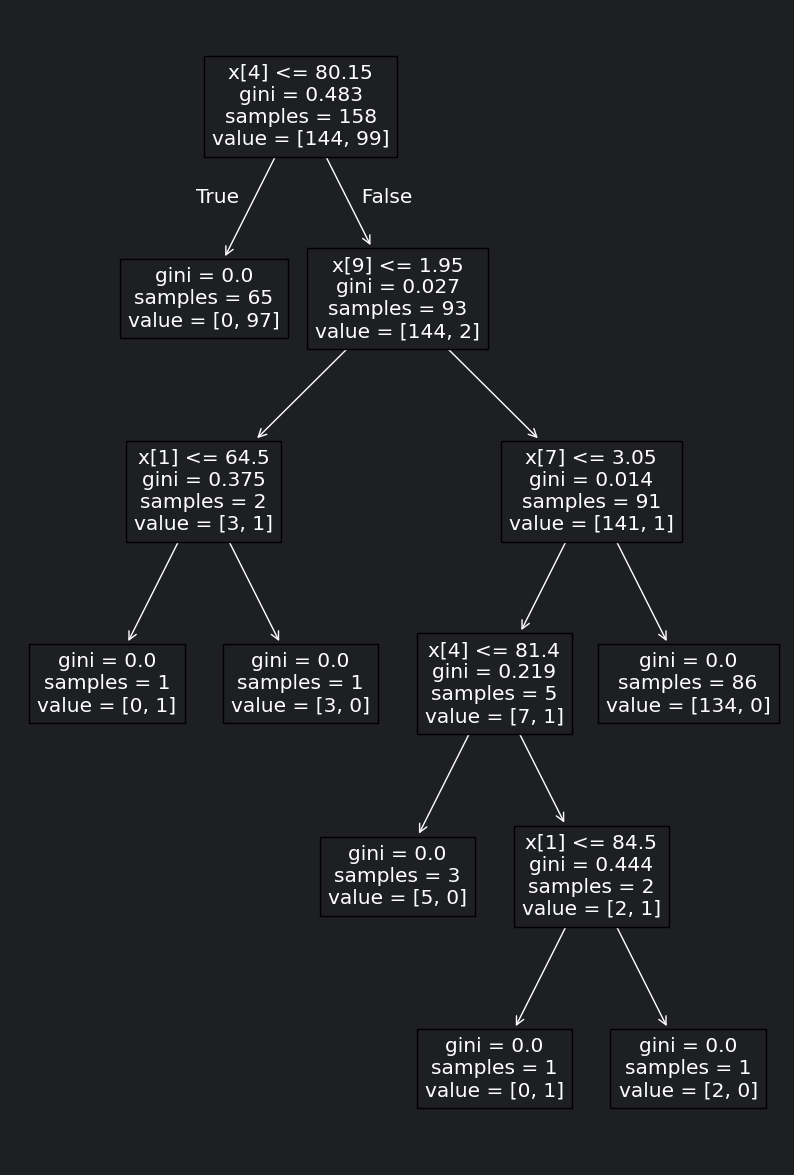

In [29]:
# Simple plot of one of the decision trees for the random forest
plt.figure(figsize=(10, 15))
tree.plot_tree(BEST_RF_CLF[2])
plt.show()

In [30]:
# Calculating Metrics
classification_accuracy = round(accuracy_score(fire_data_y, fire_predict_y) * 100, 4)
confusion_matrix = confusion_matrix(fire_data_y, fire_predict_y)
per_class_classification = classification_report(fire_data_y, fire_predict_y)

In [31]:
# Output Metrics
print(f"Classification Accuracy: {classification_accuracy}")
print(f"Confusion Matrix:\n {confusion_matrix}")
print(f"Classification Report:\n {per_class_classification}")

Classification Accuracy: 97.9424
Confusion Matrix:
 [[134   3]
 [  2 104]]
Classification Report:
               precision    recall  f1-score   support

        fire       0.99      0.98      0.98       137
    not fire       0.97      0.98      0.98       106

    accuracy                           0.98       243
   macro avg       0.98      0.98      0.98       243
weighted avg       0.98      0.98      0.98       243

